In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import hierarchical Hawkes process library
import hep

# Configure matplotlib
plt.rc('text', usetex=True)
plt.rc('font', family='times')

# Set random seed for reproducibility
np.random.seed(42)

In [24]:
## Simulation settings
T = 100  ## Total time for simulation
jumps = np.array([5, 10, 20, 40, 50, 55, 62, 70, 90, 95])  # External stimuli

# True model parameters (on standard scale, not log-scale)
lambda0_true = [2.0, 5.0, 1.0]  # Baseline intensities for the three processes
theta0_alpha_true = [10.0, 2.5, 6.5]  # Initial jump sizes for alpha process
eta_alpha_true = [5.0, 2.0, 4.0]  # Inhibition rate for alpha process
csi_alpha_true = [0.25, 0.3, 0.15]  # Recovery rate for alpha process
theta0_beta_true = [0.25, 0.1, 0.05]  # Initial jump size for beta process
eta_beta_true = [0.15, 0.1, 0.05]  # Inhibition rate for beta process
csi_beta_true = [0.1, 0.15, 0.2]  # Recovery rate for beta process

# Combine in parameter matrix
true_params = np.array([lambda0_true, theta0_alpha_true, eta_alpha_true, csi_alpha_true,
    theta0_beta_true, eta_beta_true, csi_beta_true])

# Apply log-transformation 
true_params_log = np.log(true_params)

init_params1 = [np.log(1.0), np.log(10.0), np.log(7.5), np.log(0.5), np.log(0.5), np.log(0.3), np.log(0.05), np.log(5.0)] 
init_params2 = [np.log(1.0), np.log(10.0), np.log(1.5), np.log(0.1), np.log(0.5), np.log(0.1), np.log(0.15), np.log(0.5)]
init_params3 = [np.log(1.0), np.log(1.0), np.log(5.0), np.log(0.5), np.log(0.75), np.log(0.25), np.log(0.05), np.log(1.0)]

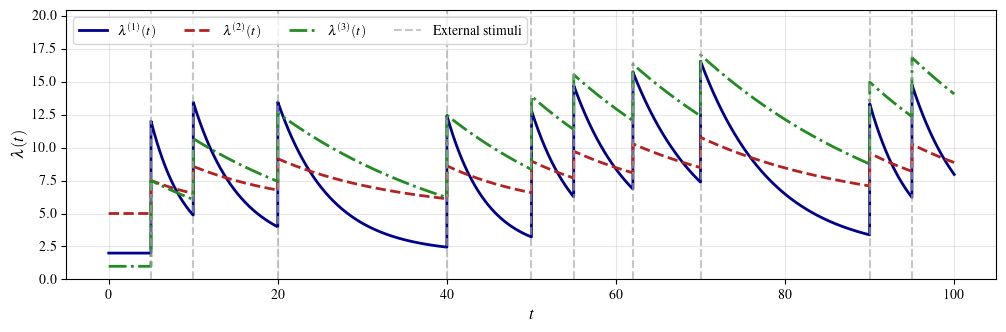

In [33]:
# Visualize the true intensity function
time_grid = np.linspace(0, T, 10000)
true_intensity = {}
K = true_params.shape[1]  # Number of groups
for k in range(K):
    true_intensity[k] = hep.calculate_intensity(
        params=true_params_log[:, k],
        t=time_grid,
        jumps=jumps,
        add_delay=False,
        fixed_jumps=False,
        fixed_decay=False,
        fixed_delay=False,
        inhibitory_decay=True,
        inhibitory_delay=False,
        log_params=True, 
        right_continuous=False
    )

# Plot the true intensity function and the jump locations
plt.figure(figsize=(12, 3.5))
cols = ['darkblue', 'firebrick', 'forestgreen']
lsty = ['-', '--', '-.']
for k in range(K):
    plt.plot(time_grid, true_intensity[k], color=cols[k], linewidth=2, label=r'$\lambda^{(' + f'{k+1}' + r')}(t)$', linestyle=lsty[k])
for jump in jumps:
    plt.axvline(x=jump, color='darkgray', linestyle='--', linewidth=1.5, alpha=0.65, label='External stimuli' if jump == jumps[0] else None)
plt.xlabel(r'$t$', fontsize=12)
plt.ylabel(r'$\lambda(t)$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0, np.max([np.max(true_intensity[k]) for k in range(K)]) * 1.2)
plt.legend(ncol=4)
plt.savefig('../figures/sim2/sim2_intensities.pdf', dpi=300, bbox_inches='tight')
plt.show()

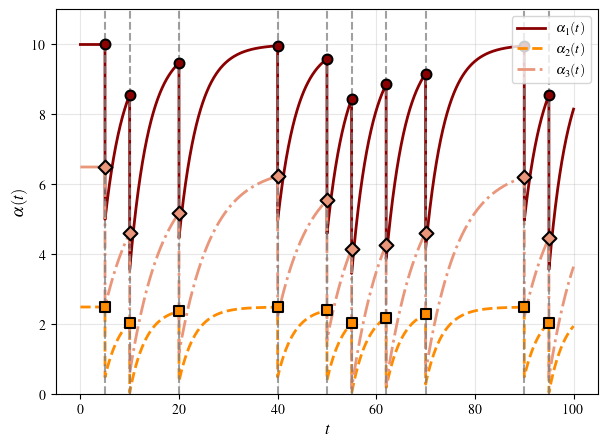

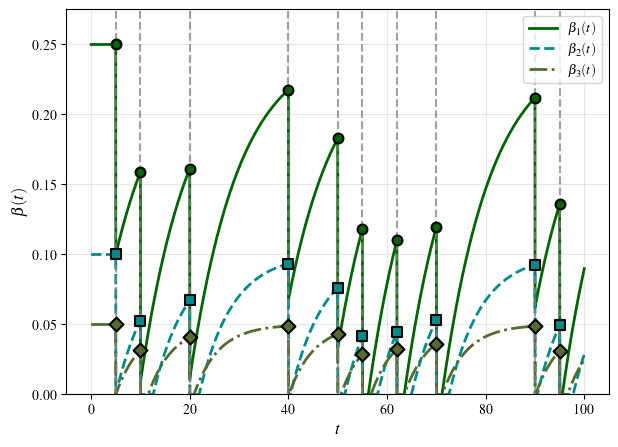

In [10]:
# Visualize the underlying hierarchical parameters alpha(t) and beta(t)
# Calculate alpha(t) and beta(t) for each time point
alphas_t = {}; alphas_at_jumps = {}
betas_t = {}; betas_at_jumps = {}
for k in range(K):
    alphas_t[k] = hep.inhibitory_hawkes_intensity(time_grid, jumps, true_params[1, k], true_params[2, k], true_params[3, k])
    betas_t[k] = hep.inhibitory_hawkes_intensity(time_grid, jumps, true_params[4, k], true_params[5, k], true_params[6, k])
    # Also calculate the values at each jump point
    alphas_at_jumps[k] = hep.inhibitory_hawkes_intensity(jumps, jumps, true_params[1, k], true_params[2, k], true_params[3, k])
    betas_at_jumps[k] = hep.inhibitory_hawkes_intensity(jumps, jumps, true_params[4, k], true_params[5, k], true_params[6, k])

# Plot alpha(t)
cols = ['darkred', 'darkorange', 'darksalmon']
lsty = ['-', '--', '-.']
marks = ['o', 's', 'D']
fig, ax = plt.subplots(figsize=(7, 5))
for k in range(K):
    ax.plot(time_grid, alphas_t[k], color=cols[k], linewidth=2, linestyle=lsty[k], label=r'$\alpha_{}(t)$'.format(k+1))
    ax.scatter(jumps, alphas_at_jumps[k], color=cols[k], s=50, zorder=5, marker=marks[k], 
           edgecolors='black', linewidth=1.5)
for jump in jumps:
    ax.axvline(x=jump, color='gray', linestyle='--', linewidth=1.5, alpha=0.75)
ax.set_xlabel(r'$t$', fontsize=12)
ax.set_ylabel(r'$\alpha(t)$', fontsize=12)
ax.set_ylim(0, np.max([np.max(alphas_t[k]) for k in range(K)]) * 1.1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Plot beta(t)
cols = ['darkgreen', 'darkcyan', 'darkolivegreen']
lsty = ['-', '--', '-.']
marks = ['o', 's', 'D']
fig, ax = plt.subplots(figsize=(7, 5))
for k in range(K):
    ax.plot(time_grid, betas_t[k], color=cols[k], linewidth=2, linestyle=lsty[k], label=r'$\beta_{}(t)$'.format(k+1))
    ax.scatter(jumps, betas_at_jumps[k], color=cols[k], s=50, zorder=5, marker=marks[k], 
               edgecolors='black', linewidth=1.5)
for jump in jumps:
    ax.axvline(x=jump, color='gray', linestyle='--', linewidth=1.5, alpha=0.75)
ax.set_xlabel(r'$t$', fontsize=12)
ax.set_ylabel(r'$\beta(t)$', fontsize=12)
ax.set_ylim(0, np.max([np.max(betas_t[k]) for k in range(K)]) * 1.1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [ ]:
## Import adjusted rand index
from sklearn.metrics import adjusted_rand_score

thresh = [7.5, 15, 22.5, 30, 37.5, 45]
n_processes = 150 # Number of processes to simulate
n_simulations = 100  # Number of simulations to run
ari = np.zeros((len(thresh), n_simulations))  # Store ARI for each simulation

for j, threshold in enumerate(thresh):
        for i in range(n_simulations):
                print(f"Threshold {threshold}\t Simulation {i+1}/{n_simulations}", end='\r')
                np.random.seed(i+2026)  # Use simulation id as seed for reproducibility
                ## Simulate events
                events = {}
                for node in range(n_processes):
                        events[node] = hep.simulate_hep(
                                params=true_params_log[:, node % K],  # Cycle through the K groups
                                jumps=jumps, T=T,
                                add_delay=False,
                                fixed_jumps=False,
                                fixed_decay=False,
                                fixed_delay=False,
                                inhibitory_decay=True,
                                inhibitory_delay=False,
                                log_params=True
                        )
                ## Select model
                model = hep.HEPMixture(K=K, jumps=jumps[jumps < threshold], add_delay=False, fixed_jumps=False, fixed_decay=False, 
                        fixed_delay=False, inhibitory_decay=True, inhibitory_delay=False, max_iter=200, tol=1e-6, verbose=False)
                ## Only filter events that occur before the threshold
                events = {node: ev[ev < threshold] for node, ev in events.items()}
                ## Fit the model with kmeans initialization
                model.fit(events, init_method='kmeans', random_state=i+117)
                ## Estimate labels using E-step
                z = model.E_step(events)[0].argmax(axis=1)
                ## Calculate ARI
                ari[j, i] = adjusted_rand_score(np.tile(np.arange(3), 50), z)


KeyboardInterrupt: 

In [22]:
## Save the ARI results
ari = np.load('ari_results_sim2.npy')
thresh = [7.5, 15, 22.5, 30, 37.5, 45]

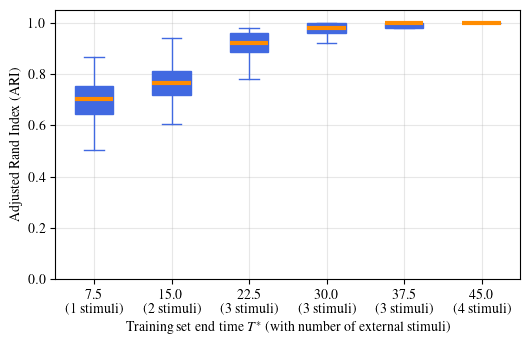

In [25]:
## Plot boxplot of ARI scores across thresholds
plt.figure(figsize=(6, 3.5))
plt.boxplot(ari.T, tick_labels=[f'{thresh[j]:.1f}' for j in range(len(thresh))], showfliers=False,
            patch_artist=True, boxprops=dict(facecolor='royalblue', color='royalblue'),
            whiskerprops=dict(color='royalblue'), capprops=dict(color='royalblue'),
            medianprops=dict(color='darkorange', linewidth=3))
## Add xticks and labels on the TOP of the plot saying the number of jumps that are included in the training set
plt.xlabel(r'Training set end time $T^\ast$ (with number of external stimuli)')
plt.ylabel('Adjusted Rand Index (ARI)')
# Positions: typically indices or data values
positions = 1+np.arange(len(thresh))
labels = [f'{thresh[j]:.1f}\n({np.sum(jumps < thresh[j])} stimuli)' for j in range(len(thresh))]
plt.xticks(positions, labels)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.savefig('../figures/sim2/ari_boxplot.pdf', bbox_inches='tight')
plt.show()

In [ ]:
thresh = [7.5, 15, 22.5, 30]
n_processes = 150 # Number of processes to simulate
n_simulations = 100  # Number of simulations to run
icls = np.zeros((len(thresh), n_simulations, 5))  # Store ICL for each simulation and K
for j, threshold in enumerate(thresh):
        for i in range(n_simulations):
                np.random.seed(i+2026)  # Use simulation id as seed for reproducibility
                ## Simulate events
                events = {}
                for node in range(n_processes):
                        events[node] = hep.simulate_hep(
                        params=true_params_log[:, node % K],  # Cycle through the K groups
                        jumps=jumps, T=T,
                        add_delay=False,
                        fixed_jumps=False,
                        fixed_decay=False,
                        fixed_delay=False,
                        inhibitory_decay=True,
                        inhibitory_delay=False,
                        log_params=True
                )
                ## Only filter events that occur before the threshold
                events = {node: ev[ev < threshold] for node, ev in events.items()}
                ## Loop over possible values of K
                for k in [1, 2, 3, 4, 5]:
                        print(f"Threshold {threshold}\t Simulation {i+1}/{n_simulations}\t\t K={k}\t\t\t", end='\r')
                        ## Select model
                        model = hep.HEPMixture(K=k, jumps=jumps[jumps < threshold], add_delay=False, fixed_jumps=False, fixed_decay=False, 
                                fixed_delay=False, inhibitory_decay=True, inhibitory_delay=False, max_iter=50, tol=1e-4, verbose=False)
                        
                        ## Fit the model with kmeans initialization
                        model.fit(events, init_method='kmeans', random_state=i+117)
                        ## Calculate ICL criterion
                        icls[j,i,k-1] = model.ICL(events)

np.save('icls_results_sim2_thresh_new_full.npy', icls)

In [9]:
np.argmax(icls, axis=2) + 2  # Add 2 to get the actual K values (since index starts at 0 for K=2)

array([[2, 2, 2, 3, 2, 2, 3, 2, 3, 2, 2, 2, 3, 2, 2, 2, 2, 2, 3, 3, 2, 3,
        3, 3, 2],
       [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3],
       [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3],
       [3, 3, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3]])

In [2]:
import numpy as np
icls = np.load('icls_results_sim2_thresh_new_full.npy')

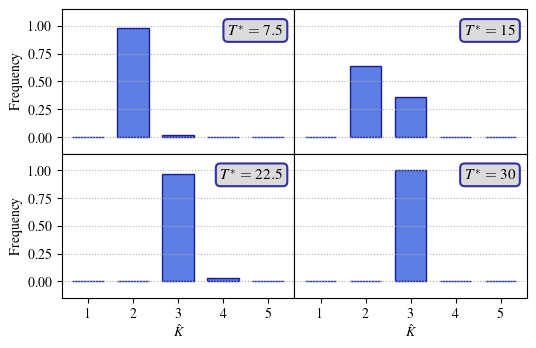

In [27]:
from collections import Counter

Ks = np.arange(1, 6)
thresh = [7.5, 15, 22.5, 30]

max_icls = np.argmax(icls, axis=2) + 1

fig, axes = plt.subplots(2, 2, figsize=(6, 3.75), sharex=True, sharey=True, 
                         gridspec_kw={'wspace': 0, 'hspace': 0})

for j, threshold in enumerate(thresh):
    counts = Counter(max_icls[j])
    y = [counts.get(k, 0) / len(max_icls[j]) for k in Ks]
    ax = axes[j // 2, j % 2]
    ax.bar(Ks, y, width=0.7, color='royalblue', edgecolor='darkblue', alpha=0.85)
    ax.set_xticks(Ks)
    # Only add x-label on bottom row
    if j // 2 == 1:
        ax.set_xlabel(r"$\hat{K}$")
    else:
        ax.tick_params(axis='x', length=0)
    # Only add y-label on left column
    if j % 2 == 0:
        ax.set_ylabel(r"Frequency")
    else:
        ax.set_yticks([0.0, 0.25, 0.50, 0.75, 1.00])
        ax.set_yticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'])
        ax.tick_params(axis='y', length=0)

    # Add threshold as text inside the plot
    ax.text(0.95, 0.9, r'$T^\ast = ' + f'{threshold}$', transform=ax.transAxes, 
            fontsize=11, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8, edgecolor='darkblue', linewidth=1.5))
    ax.set_ylim(0 - 0.15, 1. + 0.15)
    ax.grid(axis='y', alpha=1.0, linestyle='dotted')

plt.savefig('../figures/sim2/sim2_number_clusters.pdf', bbox_inches='tight')
plt.show()
